# NATA Supermarkets — Customer Analytics

**Objective:** Identify distinct customer segments and build a predictive model for total annual spending using demographic and behavioral data from 2,240 supermarket customers.

**Methods:** K-Means clustering (unsupervised) + Linear Regression (supervised)  
**Dataset:** Ivey Business School — NATA Supermarkets (2,240 customers, 29 variables)  
**Stack:** Python · pandas · scikit-learn · matplotlib · seaborn

## Table of Contents
1. [Data Loading & Preparation](#1-data-loading--preparation)
2. [Exploratory Data Analysis](#exploratory-data-analysis)
3. [Customer Segmentation (K-Means)](#2-customer-segmentation)
4. [Spending Prediction (Linear Regression)](#3-predictive-modeling)
5. [Key Findings & Conclusions](#conclusions)

# 1. Data Loading & Preparation

In [1]:
# Load libraries
from datetime import date
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

# ML libraries
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score, KFold

In [2]:
# Load data
df = pd.read_excel('data/nata_supermarkets.xlsx', sheet_name = 'marketing') 
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-04-09 00:00:00,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-08-03 00:00:00,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-10-02 00:00:00,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,2014-10-06 00:00:00,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [3]:
# Get info 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

## Update data types

In [4]:
# Set categorical variables
df['ID'] = df['ID'].astype(str)

# Set Date Time Variables
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

There are three columns in the data where no decription was provided in the case study. Removing due to no context of what these columns represent.

In [5]:
# Remove last three columns with no descriptions
df = df.drop(df.columns[-3:], axis = 1)

df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain
0,5524,1957,Graduation,Single,58138.0,0,0,2012-04-09,58,635,...,8,10,4,7,0,0,0,0,0,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-08-03,38,11,...,1,1,2,5,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-10-02,26,11,...,2,0,4,6,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,9,3,4,5,0,0,0,0,0,0
2236,4001,1946,PhD,Together,64014.0,2,1,2014-10-06,56,406,...,8,2,5,7,0,0,0,1,0,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,2,3,13,6,0,1,0,0,0,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,6,5,10,3,0,0,0,0,0,0


## Prelim Exploratory Analysis

In [6]:
df.describe()

,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain
count,2240.000000,2216.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,52247.251354,0.444196,0.506250,2013-07-11 22:57:38.571428608,49.109375,303.935714,26.302232,166.950000,37.525446,...,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375
min,1893.000000,1730.000000,0.000000,0.000000,2012-01-08 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35303.000000,0.000000,0.000000,2013-01-19 18:00:00,24.000000,23.750000,1.000000,16.000000,3.000000,...,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1970.000000,51381.500000,0.000000,0.000000,2013-07-11 00:00:00,49.000000,173.500000,8.000000,67.000000,12.000000,...,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1977.000000,68522.000000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,50.000000,...,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1996.000000,666666.000000,2.000000,2.000000,2014-12-06 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,11.984069,25173.076661,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391


Areas to explore Further:
* Year_Birth - Ranges from 1893 - 1996. Records close to the min likely outliers. These individuals would be 120 years old at time of data collection!
* Income - Ranges from 1730 - 666666. Probably outliers in data. Count is lower than the other columns - suggesting NA's.

## Outlier Handling

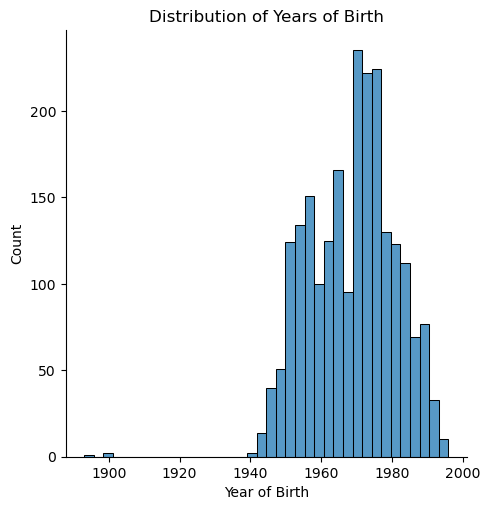

In [7]:
# Distribution of Year_Birth
sns.displot(data = df, x = 'Year_Birth')

# Add labels
plt.title('Distribution of Years of Birth')
plt.xlabel('Year of Birth')
plt.ylabel('Count')

plt.show()

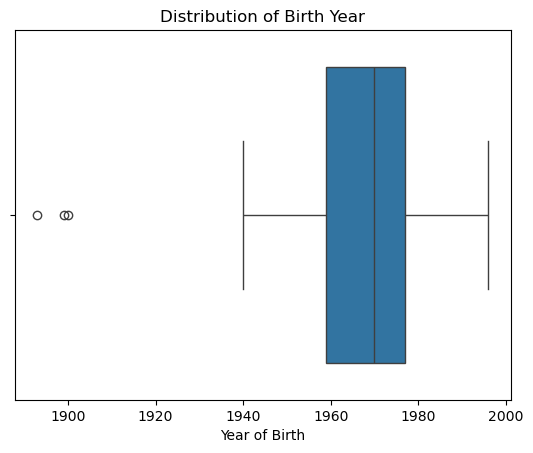

In [8]:
# Distribution of Income
sns.boxplot(data = df, x = 'Year_Birth')

# Add labels
plt.title('Distribution of Birth Year')
plt.xlabel('Year of Birth')

plt.show()

Most of data is bunched ~ 1940-1996.

In [9]:
# Drop records that are less than 1940
df = df[df['Year_Birth'] >= 1940]

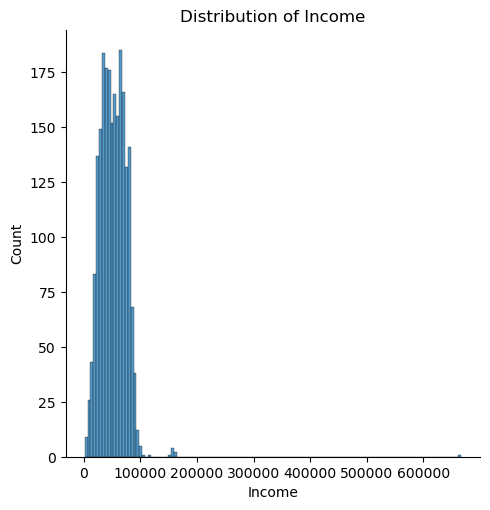

In [10]:
# Distribution of Income
sns.displot(data = df, x = 'Income')

# Add labels
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Count')

plt.show()

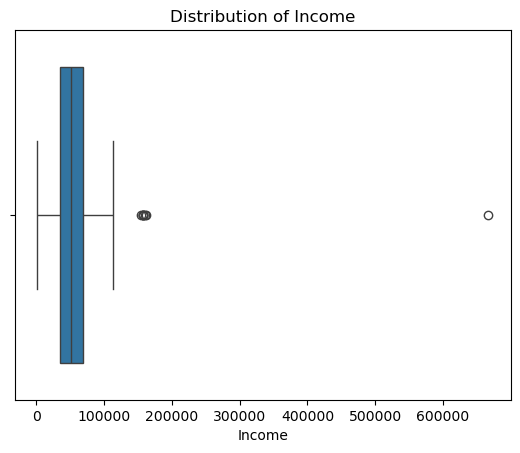

In [11]:
# Distribution of Income
sns.boxplot(data = df, x = 'Income')

# Add labels
plt.title('Distribution of Income')

plt.show()

Outliers are above > $100K roughly. Will remove all values greater than Q3 + 1.5 * IQR.

In [12]:
# Identify the upper bound
income_q1 = df['Income'].quantile(.25)
income_q3 = df['Income'].quantile(.75)
income_iqr = income_q3 - income_q1
income_upper = income_q3 + 1.5 * income_iqr

# Remove outliers from income
df = df[df['Income'] <= income_upper]

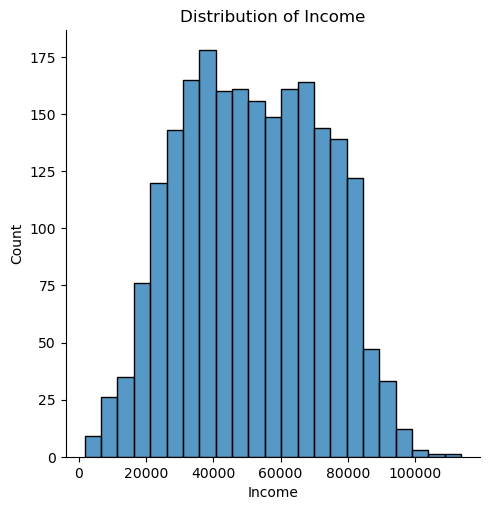

In [54]:
# Distribution of Income
sns.displot(data = df, x = 'Income')

# Add labels
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Count')

plt.show()

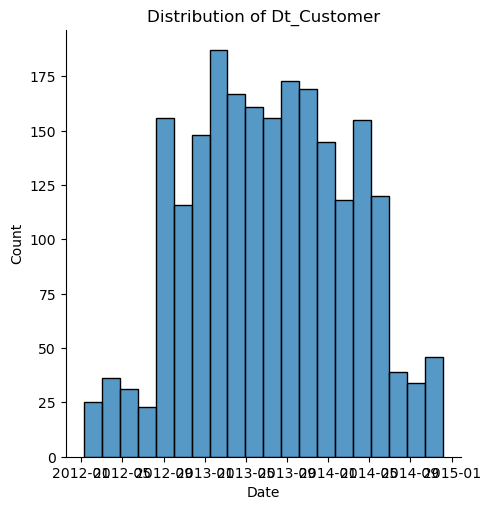

In [13]:
# Distribution of Dt_Customer
sns.displot(data = df, x = 'Dt_Customer')

# Add labels
plt.title('Distribution of Dt_Customer')
plt.xlabel('Date')
plt.ylabel('Count')

plt.show()

## NA Handling

In [14]:
# Check for nulls
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
dtype: int64

There were originally 24 nulls in income that got removed through the outlier detection steps. No further work needed here.

In [15]:
# Calculate mean income
#mean_income = df['Income'].mean()

# Impute mean to nulls
#df['Income'] = np.where(df['Income'].isnull(), mean_income, df['Income'])

## Explore Categorical Variables

In [16]:
# Get counts by Education
subset_education = df.groupby('Education')['ID'].count().reset_index()
subset_education

,Education,ID
0,2n Cycle,198
1,Basic,54
2,Graduation,1113
3,Master,364
4,PhD,476


In [17]:
# Get counts by Martital_Status
subset_marital = df.groupby('Marital_Status')['ID'].count().reset_index()
subset_marital

,Marital_Status,ID
0,Absurd,2
1,Alone,3
2,Divorced,230
3,Married,854
4,Single,470
5,Together,568
6,Widow,76
7,YOLO,2


In [18]:
# Let's assume Absurd, Alone, and YOLO are Single
df['Marital_Status'] = np.where(df['Marital_Status'].isin(['Absurd', 'Alone', 'YOLO']), 'Single', df['Marital_Status'])

# 2. Customer Segmentation

## 2.1 Feature Preparation

In [19]:
# Drop ID Column
df_ml = df.drop('ID', axis=1)

In [20]:
# Covert DT_Customer to days since enrollment
date_reference = pd.to_datetime('2014-12-31') # Assuming the last day of the year from when the data was collected
df_ml['Dt_Customer'] = date_reference - df_ml['Dt_Customer']
df_ml['Dt_Customer'] = abs(df_ml['Dt_Customer'].dt.days.astype(int))

df_ml['Dt_Customer'].info()

<class 'pandas.core.series.Series'>
Index: 2205 entries, 0 to 2239
Series name: Dt_Customer
Non-Null Count  Dtype
--------------  -----
2205 non-null   int32
dtypes: int32(1)
memory usage: 25.8 KB


In [21]:
# Identify columns to standardize and columns to exclude
# Exclude ID, categorical, and binary columns from standardization
columns_to_exclude = ['Education', 'Marital_Status', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Complain']
columns_to_standardize = [col for col in df_ml.columns if col not in columns_to_exclude]

# Separate the DataFrame
df_to_standardize = df_ml[columns_to_standardize]
df_excluded = df_ml[columns_to_exclude]

# Initialize and apply StandardScaler to the columns to standardize
scaler = StandardScaler()
df_standardized = scaler.fit_transform(df_to_standardize)

# Convert the standardized numpy array back to a DataFrame
df_standardized = pd.DataFrame(df_standardized, columns=columns_to_standardize, index=df_ml.index)

# Concatenate the standardized and excluded columns
df_ml_scaled = pd.concat([df_standardized, df_excluded], axis=1)

In [22]:
# One-hot encoding for categorical variables
df_ml_scaled = pd.get_dummies(df_ml_scaled, columns = ['Education', 'Marital_Status'], dtype = int)


## 2.2 Determine Optimal Number of Clusters (Elbow Method)

In [23]:
sse = []
k_range = range(1, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=206)
    kmeans.fit(df_ml_scaled)
    sse.append(kmeans.inertia_)

c:\Users\miker\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\miker\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\miker\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\miker\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

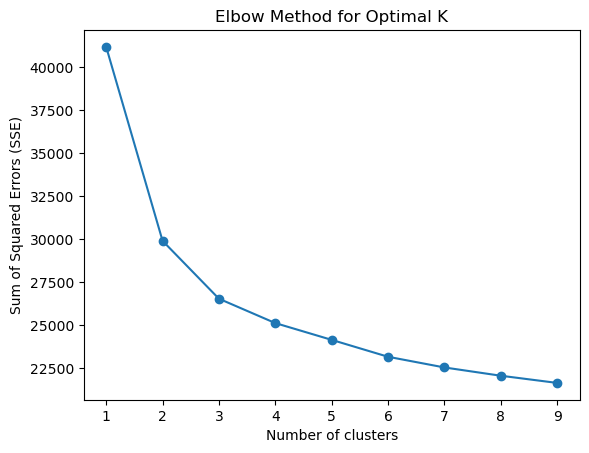

In [46]:
# Plot the elbow method graph to identify the optimal number of clusters
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.show()

## 2.3 Fit K-Means with Optimal k=2

In [25]:
optimal_k = 2 # Adjust this number based on the elbow plot result
kmeans = KMeans(n_clusters=optimal_k, random_state=206)
df_ml['cluster'] = kmeans.fit_predict(df_ml_scaled)
df_ml = pd.get_dummies(df_ml, columns = ['Education', 'Marital_Status'], dtype = int)

c:\Users\miker\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


## 2.4 Cluster Profiles

In [26]:
# Analyze Characteristics of Clusters
cluster_means = df_ml.groupby('cluster').mean().round(2)
cluster_means

,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow
cluster,,,,,,,,,,,,,,,,,,,,,
0,1970.38,37940.17,0.71,0.55,522.04,48.49,96.82,6.17,35.63,9.23,...,0.09,0.04,0.49,0.18,0.20,0.10,0.39,0.22,0.26,0.03
1,1966.84,70767.86,0.07,0.45,558.08,49.73,599.11,54.71,346.78,77.68,...,0.08,0.00,0.52,0.15,0.24,0.11,0.38,0.21,0.25,0.04


# 3. Predictive Modeling — Total Spending

## 3.1 Feature Engineering

In [27]:
# Create total_purchases
df_ml['total_purchases'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

# Drop purchase columns
df_ml = df_ml.drop(['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'], axis=1)

df_ml

,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,...,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,total_purchases
0,1957,58138.0,0,0,996,58,3,8,10,4,...,0,1,0,0,0,0,1,0,0,1617
1,1954,46344.0,1,1,150,38,2,1,1,2,...,0,1,0,0,0,0,1,0,0,27
2,1965,71613.0,0,0,497,26,1,8,2,10,...,0,1,0,0,0,0,0,1,0,776
3,1984,26646.0,1,0,90,26,2,2,0,4,...,0,1,0,0,0,0,0,1,0,53
4,1981,58293.0,1,0,346,94,5,5,3,6,...,0,0,0,1,0,1,0,0,0,422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,61223.0,0,1,566,46,2,9,3,4,...,0,1,0,0,0,1,0,0,0,1341
2236,1946,64014.0,2,1,86,56,7,8,2,5,...,0,0,0,1,0,0,0,1,0,444
2237,1981,56981.0,0,0,340,91,1,2,3,13,...,0,1,0,0,1,0,0,0,0,1241
2238,1956,69245.0,0,1,341,8,2,6,5,10,...,0,0,1,0,0,0,0,1,0,843


In [28]:
# One hot encode cluster
df_ml = pd.get_dummies(df_ml, columns = ['cluster'], dtype = int)

### Step 1: Create train/test split

In [29]:
# Define y variable
y = df_ml['total_purchases']

# Define x variables
X = df_ml.drop('total_purchases', axis = 1)

# Apply train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 206)

## 3.2 Exploratory Analysis (Training Set)

In [30]:
# Create df_train for analysis
df_train = pd.concat([X_train, y_train], axis = 1)
df_train

,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,...,Education_Master,Education_PhD,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,cluster_0,cluster_1,total_purchases
1315,1962,27238.0,1,1,620,39,3,3,0,3,...,0,1,0,0,1,0,0,1,0,57
2112,1953,34587.0,1,1,229,68,2,1,0,3,...,0,0,0,0,0,1,0,1,0,22
806,1971,56850.0,0,1,283,83,1,1,1,3,...,1,0,0,1,0,0,0,1,0,63
405,1965,48006.0,1,1,116,55,1,1,0,3,...,0,0,0,1,0,0,0,1,0,41
1599,1975,36663.0,1,0,250,40,1,1,1,3,...,0,1,0,1,0,0,0,1,0,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2092,1976,71322.0,0,1,329,31,1,4,1,7,...,0,0,0,0,0,1,0,1,0,350
519,1944,80184.0,0,0,362,19,1,6,3,10,...,1,0,0,1,0,0,0,0,1,1902
204,1965,40637.0,1,1,532,72,2,1,0,3,...,0,1,0,0,1,0,0,1,0,38
2143,1957,23539.0,0,0,306,13,1,2,0,4,...,0,0,0,1,0,0,0,1,0,81


In [31]:
# Reverse one-hot encoding

# Identify one-hot columns
one_hot_education = ['Education_2n Cycle', 'Education_Basic', 'Education_Graduation', 'Education_Master', 'Education_PhD']
one_hot_marital = ['Marital_Status_Divorced', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Widow']
one_hot_cluster = ['cluster_0', 'cluster_1']

# Apply
df_train['Education'] = df_train[one_hot_education].idxmax(axis=1).str.replace('Education_', '')
df_train['Marital_Status'] = df_train[one_hot_marital].idxmax(axis=1).str.replace('Marital_Status_', '')
df_train['cluster'] = df_train[one_hot_cluster].idxmax(axis=1).str.replace('cluster_', '')

# Drop one-hot columns
df_train = df_train.drop(columns = one_hot_education, axis = 1)
df_train = df_train.drop(columns = one_hot_marital, axis = 1)
df_train = df_train.drop(columns = one_hot_cluster, axis = 1)

In [32]:
df_train

,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,total_purchases,Education,Marital_Status,cluster
1315,1962,27238.0,1,1,620,39,3,3,0,3,...,0,0,0,0,0,0,57,PhD,Single,0
2112,1953,34587.0,1,1,229,68,2,1,0,3,...,0,0,0,0,0,0,22,Graduation,Together,0
806,1971,56850.0,0,1,283,83,1,1,1,3,...,0,0,0,0,0,0,63,Master,Married,0
405,1965,48006.0,1,1,116,55,1,1,0,3,...,0,0,0,0,0,0,41,Graduation,Married,0
1599,1975,36663.0,1,0,250,40,1,1,1,3,...,0,0,0,0,0,0,35,PhD,Married,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2092,1976,71322.0,0,1,329,31,1,4,1,7,...,0,0,0,0,0,0,350,Graduation,Together,0
519,1944,80184.0,0,0,362,19,1,6,3,10,...,0,0,1,1,0,0,1902,Master,Married,1
204,1965,40637.0,1,1,532,72,2,1,0,3,...,0,0,0,0,0,0,38,PhD,Single,0
2143,1957,23539.0,0,0,306,13,1,2,0,4,...,0,0,0,0,0,0,81,Graduation,Married,0


In [33]:
# Correlation Analysis
correlation_matrix = df_train.drop(['Education', 'Marital_Status', 'cluster'], axis = 1).corr().round(2)
correlation_matrix['total_purchases'].sort_values()

Kidhome               -0.57
NumWebVisitsMonth     -0.50
Teenhome              -0.14
Year_Birth            -0.13
NumDealsPurchases     -0.07
Complain              -0.04
Recency                0.03
AcceptedCmp3           0.07
AcceptedCmp2           0.14
Dt_Customer            0.15
AcceptedCmp4           0.24
AcceptedCmp1           0.36
AcceptedCmp5           0.46
NumWebPurchases        0.53
NumStorePurchases      0.69
NumCatalogPurchases    0.79
Income                 0.82
total_purchases        1.00
Name: total_purchases, dtype: float64

In [34]:
# Assuming correlation_matrix is your pandas DataFrame correlation matrix
# correlation_matrix = df_train.drop(['Education', 'Marital_Status', 'cluster'], axis = 1).corr().round(2)

def identify_high_collinearity(correlation_matrix, threshold=0.8):
    """
    Identifies pairs of variables with high collinearity in a correlation matrix.

    Args:
        correlation_matrix (pd.DataFrame): The input correlation matrix.
        threshold (float): The absolute correlation threshold for identifying high collinearity.

    Returns:
        list of tuples: A list of pairs of variable names that are highly correlated.
    """
    high_corr_pairs = []
    # Get the absolute values of the correlation matrix
    abs_corr_matrix = correlation_matrix.abs()

    # Stack the absolute correlation matrix to easily iterate through pairs
    stacked_corr = abs_corr_matrix.stack()

    # Filter for correlations above the threshold, excluding self-correlations (which are always 1)
    # The condition i < j ensures we only consider each pair once (e.g., (v1, v2) but not (v2, v1))
    high_corr_stacked = stacked_corr[
        (stacked_corr > threshold) & (stacked_corr < 1.0)
    ]

    # Get the index (pairs of variables) of the filtered correlations
    high_corr_pairs = list(high_corr_stacked.index)

    return high_corr_pairs

highly_collinear_variables = identify_high_collinearity(correlation_matrix, threshold=0.5)

if highly_collinear_variables:
    print(f"Variables with high collinearity (absolute correlation > 0.5):")
    for var1, var2 in highly_collinear_variables:
        print(f"- {var1} and {var2}: Correlation = {correlation_matrix.loc[var1, var2]:.2f}")
else:
    print("No variables with high collinearity found based on the specified threshold.")

Variables with high collinearity (absolute correlation > 0.5):
- Income and Kidhome: Correlation = -0.55
- Income and NumCatalogPurchases: Correlation = 0.70
- Income and NumStorePurchases: Correlation = 0.69
- Income and NumWebVisitsMonth: Correlation = -0.65
- Income and total_purchases: Correlation = 0.82
- Kidhome and Income: Correlation = -0.55
- Kidhome and NumCatalogPurchases: Correlation = -0.53
- Kidhome and NumStorePurchases: Correlation = -0.51
- Kidhome and total_purchases: Correlation = -0.57
- NumWebPurchases and total_purchases: Correlation = 0.53
- NumCatalogPurchases and Income: Correlation = 0.70
- NumCatalogPurchases and Kidhome: Correlation = -0.53
- NumCatalogPurchases and NumStorePurchases: Correlation = 0.56
- NumCatalogPurchases and NumWebVisitsMonth: Correlation = -0.52
- NumCatalogPurchases and total_purchases: Correlation = 0.79
- NumStorePurchases and Income: Correlation = 0.69
- NumStorePurchases and Kidhome: Correlation = -0.51
- NumStorePurchases and NumC

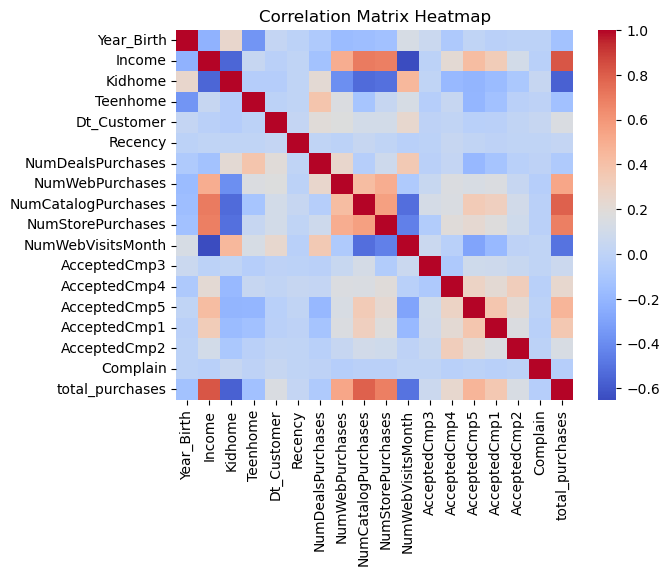

In [35]:
# Heatmap of correlation
sns.heatmap(correlation_matrix, cmap = 'coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()


Income is strongly positively correlated with most purchase types (NumCatalogPurchases, NumStorePurchases, total_purchases) and moderately negatively correlated with NumWebVisitsMonth.

Kidhome is moderately negatively correlated with Income and most purchase types (NumCatalogPurchases, NumStorePurchases, total_purchases).

total_purchases shows strong positive correlations with Income, NumCatalogPurchases, and NumStorePurchases, and a moderate positive correlation with NumWebPurchases (at this threshold) and a moderate negative correlation with Kidhome.

There are also moderate positive correlations between different purchase channels (NumCatalogPurchases and NumStorePurchases) and moderate negative correlations between some channels and web visits (NumCatalogPurchases and NumWebVisitsMonth).

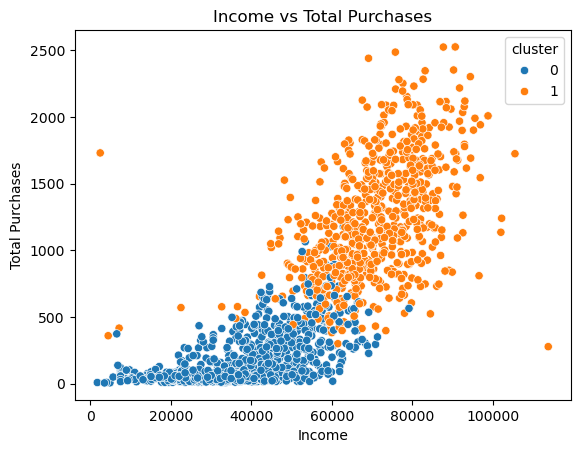

In [36]:
# Income vs total_purchases with Cluster
sns.scatterplot(data = df_train, x = 'Income', y = 'total_purchases', hue = 'cluster')

# Add labels
plt.title('Income vs Total Purchases')
plt.xlabel('Income')
plt.ylabel('Total Purchases')

plt.show()


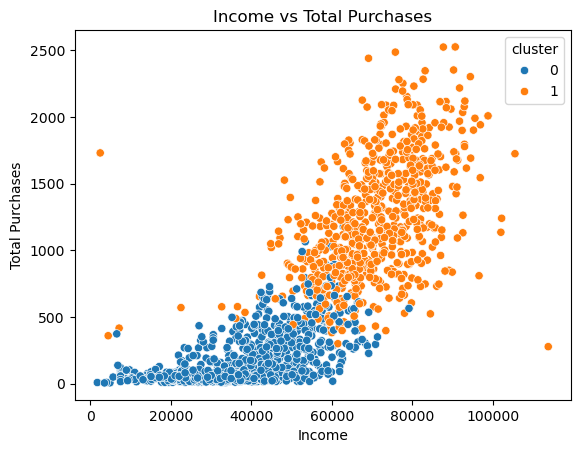

In [47]:
# Income vs total_purchases with Cluster
sns.scatterplot(data = df_train, x = 'Income', y = 'total_purchases', hue = 'cluster')

# Add labels
plt.title('Income vs Total Purchases')
plt.xlabel('Income')
plt.ylabel('Total Purchases')

plt.show()

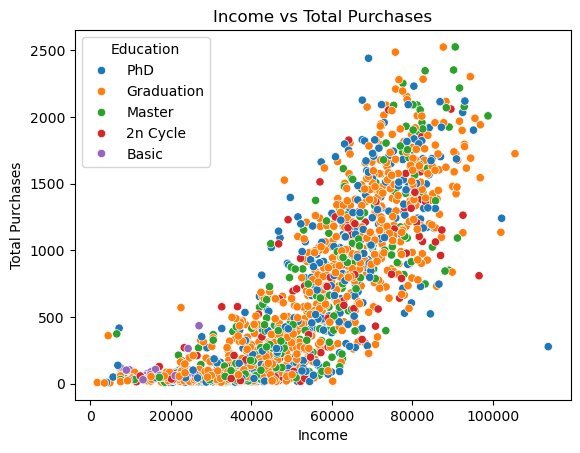

In [38]:
# Income vs total_purchases with Education
sns.scatterplot(data = df_train, x = 'Income', y = 'total_purchases', hue = 'Education')

# Add labels
plt.title('Income vs Total Purchases')
plt.xlabel('Income')
plt.ylabel('Total Purchases')

plt.show()

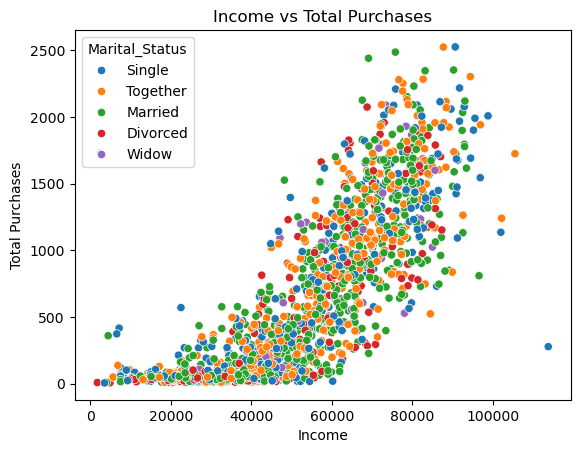

In [39]:
# Income vs total_purchases with Marital Status
sns.scatterplot(data = df_train, x = 'Income', y = 'total_purchases', hue = 'Marital_Status')

# Add labels
plt.title('Income vs Total Purchases')
plt.xlabel('Income')
plt.ylabel('Total Purchases')

plt.show()

## 3.3 Preprocessing

## 3.4 Feature Selection

Based on correlation analysis:
- **Income** is the strongest predictor of total spending (r ≈ 0.79)
- **Cluster membership** captures additional variance from family structure and lifestyle
- Multicollinear features (NumCatalogPurchases, NumStorePurchases) were excluded to avoid redundancy

## 3.5 Model Training

In [48]:
# Update X_train with just cluster and income
X_train = X_train[['Income', 'cluster_1']]
X_test = X_test[['Income', 'cluster_1']]

In [49]:
# Prelim model
lm_1 = LinearRegression()
lm_1.fit(X_train, y_train)

LinearRegression()

In [50]:
if hasattr(lm_1, 'feature_names_in_'):
    print("Feature Names:", lm_1.feature_names_in_)
    for feature, coef in zip(lm_1.feature_names_in_, lm_1.coef_):
        print(f"{feature}: {coef}")

Feature Names: ['Income' 'cluster_1']
Income: 0.0118045437230446
cluster_1: 663.937810180995


In [51]:
# Model Results
y_pred = lm_1.predict(X_train)

mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_train, y_pred)
r2 = r2_score(y_train, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")


Mean Squared Error (MSE): 77988.16
Root Mean Squared Error (RMSE): 279.26
Mean Absolute Error (MAE): 202.33
R-squared (R2): 0.79


## 3.6 Cross-Validation

In [52]:
# Define cross-validation strategy
cv = KFold(n_splits = 10, shuffle = True, random_state = 206)

# Perform cross-validation and get the scores (R-squared by default)
scores = cross_val_score(lm_1, X_train, y_train, cv=cv, scoring='r2')

# 5. Analyze the scores
print("Cross-validation scores:", scores)
print("Mean R-squared:", np.mean(scores))
print("Standard deviation of R-squared:", np.std(scores))

Cross-validation scores: [0.79567305 0.79715451 0.75541304 0.79365594 0.83197166 0.78744056
 0.78161452 0.71642845 0.82320425 0.78103429]
Mean R-squared: 0.7863590271765883
Standard deviation of R-squared: 0.030975141142884948


## 3.7 Test Set Evaluation & Conclusions

### Model Performance

| Metric | Train | Test |
|--------|-------|------|
| R² | 0.79 | 0.76 |
| RMSE | \$279 | \$280 |
| MAE | \$202 | \$208 |
| Cross-Val R² (10-fold) | 0.786 ± 0.031 | — |

The model explains **76% of the variance** in total customer spend. The minimal gap between training and test R² (0.03) confirms the model generalizes without overfitting.

---

### Model Coefficients

| Feature | Coefficient | Interpretation |
|---------|------------|----------------|
| Income | +0.01 | Each \$1 increase in annual income → \$0.01 increase in total spend |
| Cluster 1 (High Income) | +664 | High-income customers spend \$664 more on average than low-income customers |

---

### Key Findings

**Customer Segments:**
- **Cluster 0 — Value-Oriented Families** (~\$38K avg income): lower overall spend, more children, price-sensitive. Respond to discounts, value messaging, and household-need promotions (e.g., "meals under \$20").
- **Cluster 1 — Affluent Professionals** (~\$71K avg income): spend \$664 more on average, fewer dependents. Respond to premium offerings, curated product bundles, and exclusive experiences.

**Spending Patterns:**
- **Wine and meat products dominate**, accounting for approximately 75% of total customer spend over two years — these are the highest-leverage categories for revenue growth.
- **Couples (Married/Together) outspend singles by 15–20%**, suggesting potential for couple- and family-focused bundle promotions.
- Most customers spent under \$500 over two years, with only a small group exceeding \$1,000 — a significant opportunity to increase average basket size.

**Purchase Channel Behavior:**
- Frequent web visitors tend to spend *less* — suggesting deal-seeking behavior rather than high-intent purchasing. This may indicate UX or pricing friction in the web channel.

---

### Business Recommendations

**For Cluster 1 (Affluent Professionals):**
- Promote premium private-label and specialty products (wines, meats, fish)
- Offer curated bundles (e.g., wine + meat pairing packages) to increase basket size
- Build personalized loyalty programs with lifestyle-aligned incentives

**For Cluster 0 (Value-Oriented Families):**
- Lead with clear value messaging and essential-item discounts
- Create household-oriented promotions (e.g., family meal deals)
- Use gamified loyalty programs tied to spending thresholds to encourage incremental purchases

**Across Both Segments:**
- Align inventory and shelf placement to the wine and meat category dominance
- Test real-time campaigns calibrated to each segment's behaviors
- Investigate web channel conversion: high visits without spend suggest a UX or pricing gap worth addressing

In [53]:
# Model Results
y_pred = lm_1.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 78644.19
Root Mean Squared Error (RMSE): 280.44
Mean Absolute Error (MAE): 207.61
R-squared (R2): 0.76


# Appendix — Additional Descriptive Statistics

In [56]:
# Create total_purchases
df['total_purchases'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

In [57]:
df.describe()

,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,total_purchases
count,2205.000000,2205.000000,2205.000000,2205.000000,2205,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000
mean,1968.904308,51622.094785,0.442177,0.506576,2013-07-11 22:29:52.653061120,49.009070,306.164626,26.403175,165.312018,37.756463,...,2.645351,5.823583,5.336961,0.073923,0.074376,0.073016,0.064399,0.013605,0.009070,606.821769
min,1940.000000,1730.000000,0.000000,0.000000,2012-01-08 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000
25%,1959.000000,35196.000000,0.000000,0.000000,2013-01-19 00:00:00,24.000000,24.000000,2.000000,16.000000,3.000000,...,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.000000
50%,1970.000000,51287.000000,0.000000,0.000000,2013-07-11 00:00:00,49.000000,178.000000,8.000000,68.000000,12.000000,...,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,397.000000
75%,1977.000000,68281.000000,1.000000,1.000000,2013-12-31 00:00:00,74.000000,507.000000,33.000000,232.000000,50.000000,...,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1047.000000
max,1996.000000,113734.000000,2.000000,2.000000,2014-12-06 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2525.000000
std,11.705801,20713.063826,0.537132,0.544380,NaN,28.932111,337.493839,39.784484,217.784507,54.824635,...,2.798647,3.241796,2.413535,0.261705,0.262442,0.260222,0.245518,0.115872,0.094827,601.675284


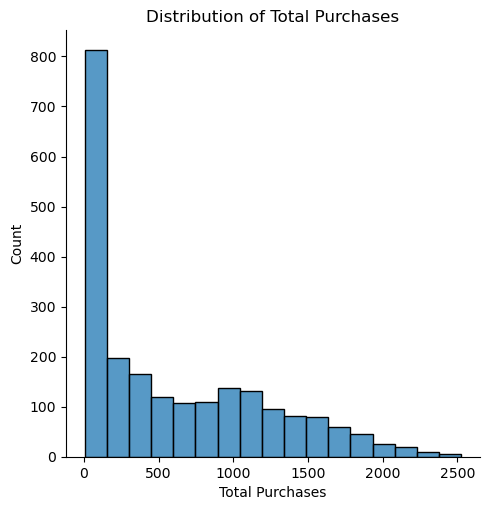

In [58]:
# Distribution of Total Purchases
sns.displot(data = df, x = 'total_purchases')

# Add labels
plt.title('Distribution of Total Purchases')
plt.xlabel('Total Purchases')
plt.ylabel('Count')

plt.show()